In [472]:
import numpy as np 
import polars as pl 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [473]:
df = pl.scan_csv(r'C:\Users\erics\courses\gradml1\crypto_pred_market\data_gather\final_data\final_data.csv').collect()
df = df.filter(pl.col('time_to_close').is_between(0,300))

In [474]:
df.head()

curr_time,open_time,close_time,prev_time,time_to_close,last_price_dollars,yes_mid_dollars,yes_spread_dollars,distance_from_strike,yes_mid_change_1s,yes_mid_change_5s,yes_mid_change_std_30s,yes_mid_change_std_60s,yes_spread_mean_30s,yes_ask_dollars,yes_bid_dollars,no_ask_dollars,no_bid_dollars,next_price_dollars_lead1,outcome,ETH_last_price_dollars,ETH_yes_mid_dollars,ETH_yes_spread_dollars,ETH_distance_from_strike,ETH_yes_mid_change_1s,ETH_yes_mid_change_5s,ETH_yes_mid_change_std_30s,ETH_yes_mid_change_std_60s,ETH_yes_spread_mean_30s,ETH_yes_ask_dollars,ETH_yes_bid_dollars,ETH_no_ask_dollars,ETH_no_bid_dollars,XRP_last_price_dollars,XRP_yes_mid_dollars,XRP_yes_spread_dollars,XRP_distance_from_strike,XRP_yes_mid_change_1s,XRP_yes_mid_change_5s,XRP_yes_mid_change_std_30s,XRP_yes_mid_change_std_60s,XRP_yes_spread_mean_30s,XRP_yes_ask_dollars,XRP_yes_bid_dollars,XRP_no_ask_dollars,XRP_no_bid_dollars,SOL_last_price_dollars,SOL_yes_mid_dollars,SOL_yes_spread_dollars,SOL_distance_from_strike,SOL_yes_mid_change_1s,SOL_yes_mid_change_5s,SOL_yes_mid_change_std_30s,SOL_yes_mid_change_std_60s,SOL_yes_spread_mean_30s,SOL_yes_ask_dollars,SOL_yes_bid_dollars,SOL_no_ask_dollars,SOL_no_bid_dollars,btc_spot_price,btc_spot_size_1s,btc_spot_signed_size_1s,btc_spot_return_1s,btc_spot_return_5s,btc_spot_return_15s,btc_spot_return_60s,btc_spot_return_vol_30s,btc_spot_return_vol_5m,btc_spot_signed_flow_mean_30s,btc_spot_size_mean_30s
str,str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2026-03-21T10:54:59.610960+000…","""2026-03-21T10:45:00.000000+000…","""2026-03-21T11:00:00.000000+000…","""2026-03-21T10:54:58.610165+000…",300,0.39,0.395,0.01,-2.4,0.0,0.0,0.014606,0.014276,0.01,0.4,0.39,0.61,0.6,0.39,1,0.07,0.053,0.026,-1.61,0.0,0.0,0.002921,0.003334,0.024133,0.066,0.04,0.96,0.934,0.21,0.215,0.01,-0.0007,0.075,0.075,0.013693,0.009682,0.019667,0.22,0.21,0.79,0.78,0.29,0.285,0.01,-0.0388,0.0,0.0,0.002739,0.004886,0.015,0.29,0.28,0.72,0.71,70578.75,0.000647,-0.000647,0.0,0.000107,0.000107,0.000033,0.000028,0.000021,-0.00399,0.004843
"""2026-03-21T10:55:00.612308+000…","""2026-03-21T10:45:00.000000+000…","""2026-03-21T11:00:00.000000+000…","""2026-03-21T10:54:59.610960+000…",299,0.39,0.395,0.01,-2.4,0.0,0.0,0.014606,0.014276,0.01,0.4,0.39,0.61,0.6,0.39,1,0.07,0.053,0.026,-1.6,0.0,0.0,0.002921,0.003334,0.0244,0.066,0.04,0.96,0.934,0.21,0.215,0.01,-0.0007,0.0,0.075,0.013693,0.009682,0.019333,0.22,0.21,0.79,0.78,0.29,0.285,0.01,-0.0388,0.0,0.0,0.002739,0.004886,0.014667,0.29,0.28,0.72,0.71,70578.75,4.4000e-7,-4.4000e-7,0.0,0.0,0.000107,0.000033,0.000028,0.000021,-0.00399,0.004843
"""2026-03-21T10:55:01.612987+000…","""2026-03-21T10:45:00.000000+000…","""2026-03-21T11:00:00.000000+000…","""2026-03-21T10:55:00.612308+000…",298,0.39,0.395,0.01,-2.4,0.0,0.0,0.014606,0.014276,0.01,0.4,0.39,0.61,0.6,0.39,1,0.07,0.053,0.026,-1.6,0.0,0.0,0.002921,0.003334,0.024667,0.066,0.04,0.96,0.934,0.21,0.215,0.01,-0.0007,0.0,0.075,0.013693,0.009682,0.019,0.22,0.21,0.79,0.78,0.29,0.285,0.01,-0.0388,0.0,0.0,0.002739,0.004886,0.014333,0.29,0.28,0.72,0.71,70578.75,0.002806,-0.002806,0.0,0.0,0.000107,0.000033,0.000028,0.000021,-0.004083,0.004937
"""2026-03-21T10:55:02.613898+000…","""2026-03-21T10:45:00.000000+000…","""2026-03-21T11:00:00.000000+000…","""2026-03-21T10:55:01.612987+000…",297,0.39,0.395,0.01,-2.4,0.0,0.0,0.014606,0.014276,0.01,0.4,0.39,0.61,0.6,0.39,1,0.07,0.053,0.026,-1.6,0.0,0.0,0.002921,0.003334,0.024933,0.066,0.04,0.96,0.934,0.21,0.215,0.01,-0.001,0.0,0.075,0.013693,0.009682,0.018667,0.22,0.21,0.79,0.78,0.29,0.285,0.01,-0.0388,0.0,0.0,0.002739,0.004886,0.014,0.29,0.28,0.72,0.71,70578.75,4.4000e-7,-4.4000e-7,0.0,0.0,0.000107,0.000033,0.000028,0.000021,-0.004083,0.004937
"""2026-03-21T10:55:03.615305+000…","""2026-03-21T10:45:00.000000+00

In [475]:
df.shape

(350163, 70)

In [476]:
np.median(df['yes_mid_dollars'])



np.float64(0.495)

In [477]:
def _to_datetime(table: pl.DataFrame, cols: list) -> pl.DataFrame:
        for col in cols: 
            table = table.with_columns(
                pl.col(col)
                .str.to_datetime(format="%Y-%m-%dT%H:%M:%S%.f%#z", strict=False)
                .alias(col)
            )
        return table

df = _to_datetime(df, cols = ['curr_time', 'open_time', 'close_time', 'prev_time'])


In [478]:
event_col_ids = ['open_time', 'close_time']
event_ids = (df.select(event_col_ids).unique().sort('open_time'))
n = 0.7

X_train_ids = event_ids[:round(n*len(event_ids))]
X_test_ids = event_ids[round(n*len(event_ids)):]

y_train = df.join(X_train_ids, on=event_col_ids, how = 'inner').select('outcome')
X_train = df.join(X_train_ids, on=event_col_ids, how = 'inner').drop('curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1')

y_test = df.join(X_test_ids, on=event_col_ids, how = 'inner').select('outcome')
X_test = df.join(X_test_ids, on=event_col_ids, how = 'inner').drop('curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1')



In [479]:
from sklearn.model_selection import GroupShuffleSplit

groups = df['open_time'].cast(str) + '_' + df['close_time'].cast(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.1)
train_idx, test_idx = next(gss.split(df, groups=groups.to_numpy()))

drop_cols = ['curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1']

X_train = df[train_idx].drop(drop_cols)
y_train = df[train_idx].select('outcome')
X_test = df[test_idx].drop(drop_cols)
y_test = df[test_idx].select('outcome')

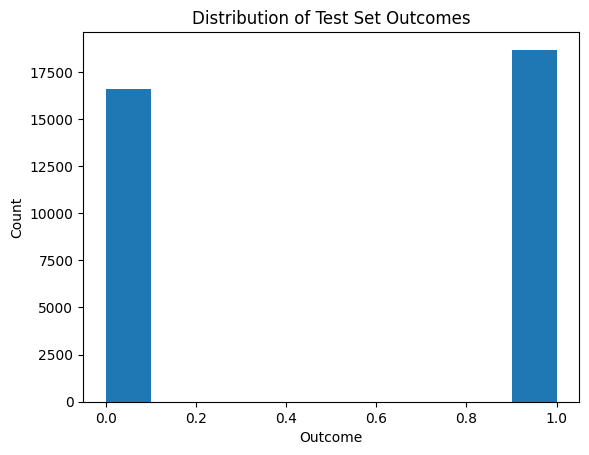

In [480]:
import matplotlib.pyplot as plt 
plt.hist(y_test)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Test Set Outcomes')
plt.show()

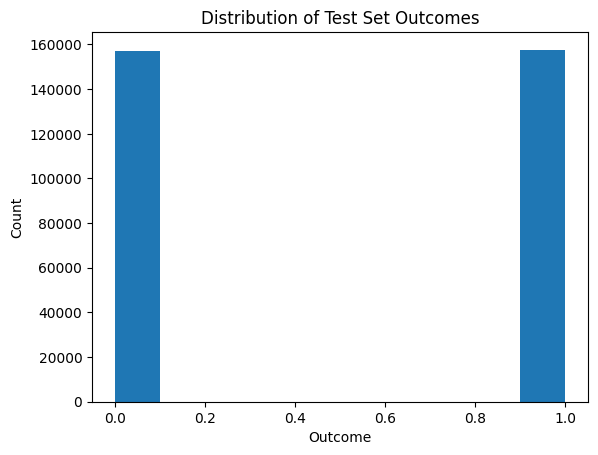

In [481]:
import matplotlib.pyplot as plt 
plt.hist(y_train)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Test Set Outcomes')
plt.show()

In [482]:
log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_reg.fit(X_train.to_numpy(), y_train.to_numpy().ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [483]:
log_reg.score(X_test.to_numpy(), y_test.to_numpy().ravel())
y_pred = log_reg.predict(X_test.to_numpy())
print("Accuracy:", accuracy_score(y_test.to_numpy().ravel(), y_pred))
print(confusion_matrix(y_test.to_numpy().ravel(), y_pred))
print(classification_report(y_test.to_numpy().ravel(), y_pred))

Accuracy: 0.900082248503928
[[14905  1679]
 [ 1844 16831]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     16584
           1       0.91      0.90      0.91     18675

    accuracy                           0.90     35259
   macro avg       0.90      0.90      0.90     35259
weighted avg       0.90      0.90      0.90     35259



In [484]:
# probability of class 1 p_hat := [class0_prob, class1_prob]
p_hat = log_reg.predict_proba(X_test.to_numpy())[:,-1]
q = df[test_idx].select('yes_mid_dollars').to_numpy().ravel()

p_hat - q

ev_yes = p_hat - q 
ev_no = q-p_hat

threshold = 0.1 
ev_yes

array([0.0557838 , 0.05889347, 0.05892119, ..., 0.04182694, 0.04052298,
       0.04142621], shape=(35259,))

In [523]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit

groups = df["open_time"].cast(str) + "_" + df["close_time"].cast(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.3)
train_idx, test_idx = next(gss.split(df, groups=groups.to_numpy()))

drop_cols = [
    "curr_time",
    "outcome",
    "open_time",
    "close_time",
    "prev_time",
    "next_price_dollars_lead1",
]

X_train = df[train_idx].drop(drop_cols)
y_train = df[train_idx].select("outcome")
X_test = df[test_idx].drop(drop_cols)
y_test = df[test_idx].select("outcome")

X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy().ravel()
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy().ravel()

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=10000)
)

model.fit(X_train_np, y_train_np)

p_hat = model.predict_proba(X_test_np)[:, 1]

q_mid = X_test["yes_mid_dollars"].to_numpy().ravel()
yes_ask = X_test["yes_ask_dollars"].to_numpy().ravel()
no_ask = X_test["no_ask_dollars"].to_numpy().ravel()

# Signal generation uses midpoint
signal_yes = p_hat - q_mid
signal_no = q_mid - p_hat

# threshold = 0.1

threshold_lst = []
pnl_lst = []
num_trades_lst = []
wr_list =[]

for t in range(99): 
    threshold = t/100

    position = np.zeros(len(p_hat))
    position[signal_yes > threshold] = 1
    position[signal_no > threshold] = -1

    # Executable EV uses actual ask prices
    ev_yes_exec = p_hat - yes_ask
    ev_no_exec = (1 - p_hat) - no_ask

    pnl = np.zeros(len(p_hat))

    yes_mask = position == 1
    pnl[yes_mask] = np.where(
        y_test_np[yes_mask] == 1,
        1 - yes_ask[yes_mask]-0.02,
        -yes_ask[yes_mask]-0.02
    )

    no_mask = position == -1
    pnl[no_mask] = np.where(
        y_test_np[no_mask] == 0,
        1 - no_ask[no_mask]-0.02,
        -no_ask[no_mask]-0.02
    )

    # trade_ev = np.where(
    #     position == 1,
    #     ev_yes_exec,
    #     np.where(position == -1, ev_no_exec, np.nan)
    # )

    trade_mask = position != 0
    threshold_lst.append(threshold)
    if trade_mask.sum() > 0:
        pnl_lst.append(pnl[trade_mask].sum())
    else:
        pnl_lst.append(np.nan)

    num_trades_lst.append(trade_mask.sum())
    wr_list.append((pnl[trade_mask] > 0).mean() if trade_mask.sum() > 0 else np.nan)

# print("Number of trades:", trade_mask.sum())
# print("Average signal of trades:", np.nanmean(np.where(position == 1, signal_yes, np.where(position == -1, signal_no, np.nan))))
# print("Average executable EV of trades:", np.nanmean(trade_ev))
# print("Average PnL per trade:", pnl[trade_mask].mean())
# print("Total PnL:", pnl[trade_mask].sum())
# print("Win rate:", (pnl[trade_mask] > 0).mean())
# print("Worst trade:", pnl[trade_mask].min())
# print("5th percentile PnL:", np.quantile(pnl[trade_mask], 0.05))



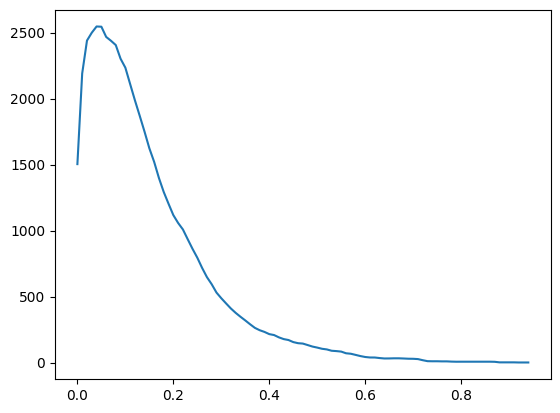

In [525]:
plt.plot(threshold_lst, pnl_lst)
# plt.plot(threshold_lst, np.log(num_trades_lst))